<a href="https://colab.research.google.com/github/cosmyyyyyyyy12/CreditGuard-Loan-Default-Risk-Modeling-System/blob/main/CreditGuard_Loan_Default_Risk_Modeling_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

In [ ]:
dfog = pd.read_csv("https://raw.githubusercontent.com/cosmyyyyyyyy12/CreditGuard-Loan-Default-Risk-Modeling-System/refs/heads/main/loan_risk_prediction_dataset.csv")
df = dfog.copy()

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1
3,32,56307.0,11531.0,549.0,11,Male,NaN,New York,Unemployed,0
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0


In [ ]:
df.shape

(5000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              5000 non-null   int64  
 1   Income           4804 non-null   float64
 2   LoanAmount       5000 non-null   float64
 3   CreditScore      4806 non-null   float64
 4   YearsExperience  5000 non-null   int64  
 5   Gender           5000 non-null   object 
 6   Education        4802 non-null   object 
 7   City             5000 non-null   object 
 8   EmploymentType   5000 non-null   object 
 9   LoanApproved     5000 non-null   int64  
dtypes: float64(3), int64(3), object(4)
memory usage: 390.8+ KB


In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,5000.000000,4804.000000,5000.000000,4806.000000,5000.000000,5000.000000
mean,43.584600,49738.123022,19870.768600,575.494590,19.599000,0.230200
std,14.919094,15101.361851,8046.542413,160.550839,11.516837,0.421003
min,18.000000,-3731.000000,-10059.000000,300.000000,0.000000,0.000000
25%,31.000000,39608.500000,14455.250000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19842.500000,579.000000,20.000000,0.000000
75%,56.000000,59917.000000,25326.750000,712.000000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
invalid_index = df[df['LoanAmount'] < 0].index
df = df.drop(invalid_index).reset_index(drop=True)

In [ ]:
df.describe()

,Age,Income,LoanAmount,CreditScore,YearsExperience,LoanApproved
count,4972.000000,4776.000000,4972.000000,4780.000000,4972.000000,4972.000000
mean,43.569187,49731.345896,19998.768504,575.201674,19.591714,0.230692
std,14.925802,15075.442943,7883.901387,160.540925,11.519090,0.421318
min,18.000000,-3731.000000,4.000000,300.000000,0.000000,0.000000
25%,31.000000,39629.000000,14541.750000,433.000000,10.000000,0.000000
50%,43.000000,49488.000000,19881.000000,579.000000,20.000000,0.000000
75%,56.000000,59895.000000,25363.500000,711.250000,29.000000,0.000000
max,69.000000,99146.000000,48353.000000,849.000000,39.000000,1.000000


In [ ]:
df.isnull().sum()

,0
Age,0
Income,196
LoanAmount,0
CreditScore,192
YearsExperience,0
Gender,0
Education,198
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
df['Income'] = df['Income'].fillna(0)
df['CreditScore'] = df['CreditScore'].fillna(350)
df['Education'] = df['Education'].fillna('No Education')

In [ ]:
df.isnull().sum()

,0
Age,0
Income,0
LoanAmount,0
CreditScore,0
YearsExperience,0
Gender,0
Education,0
City,0
EmploymentType,0
LoanApproved,0


In [ ]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved'],
      dtype='object')

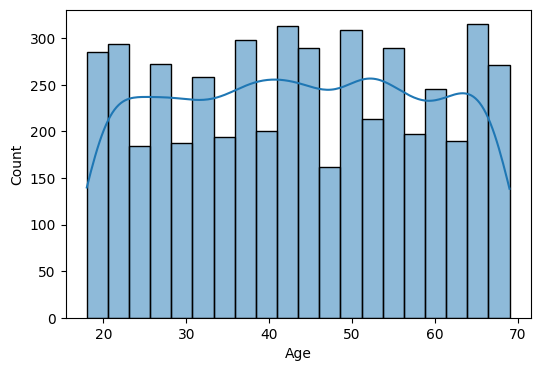

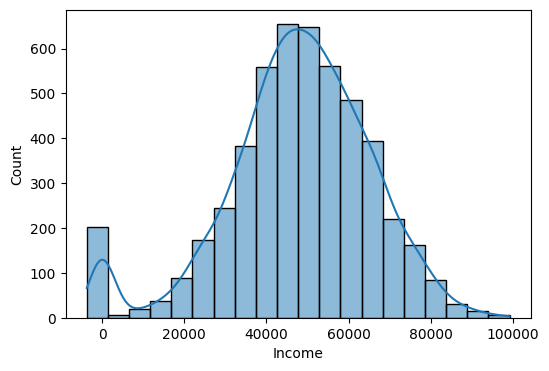

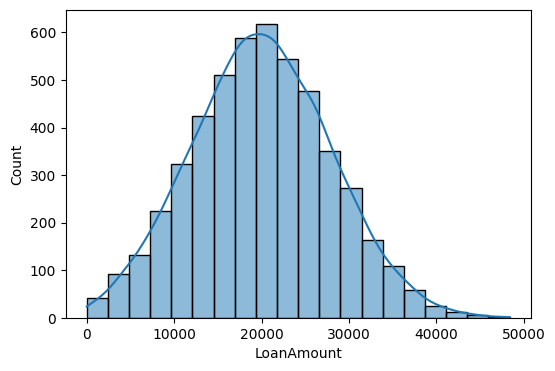

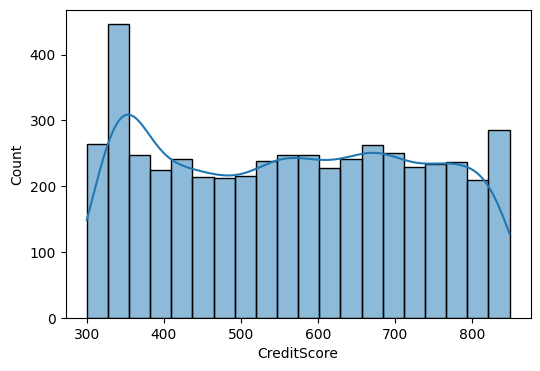

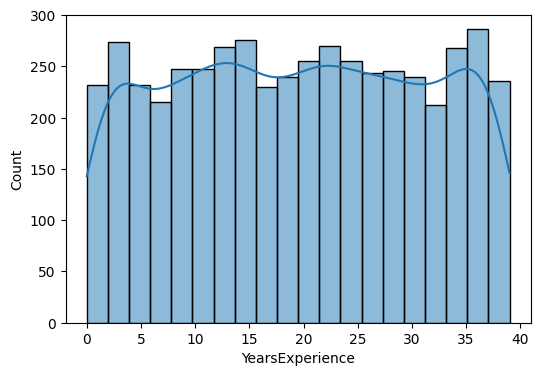

In [ ]:
numeric_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience']
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.histplot(df[cols], kde = True, bins = 20)

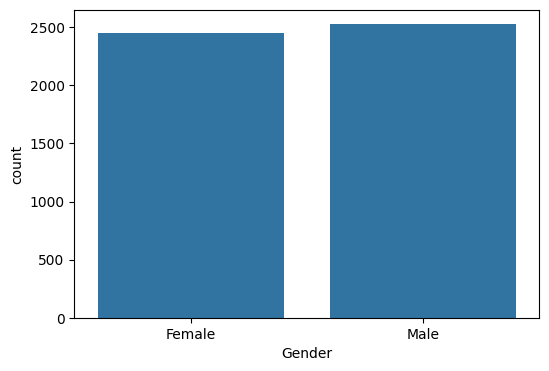

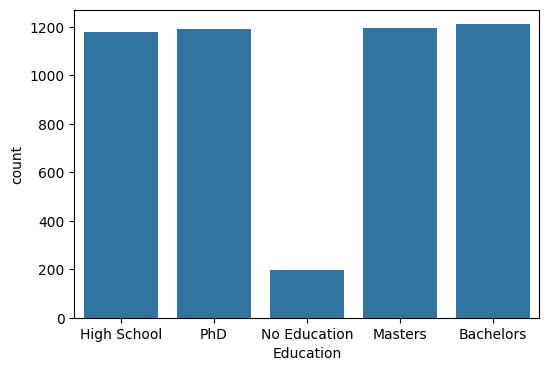

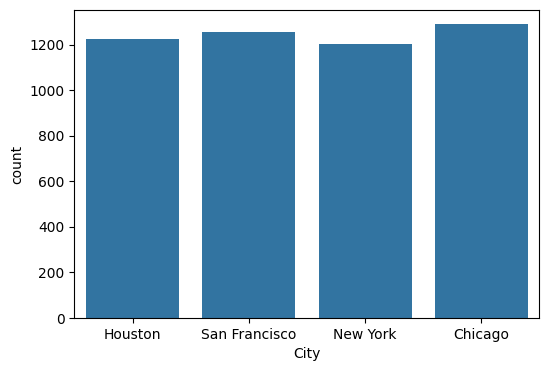

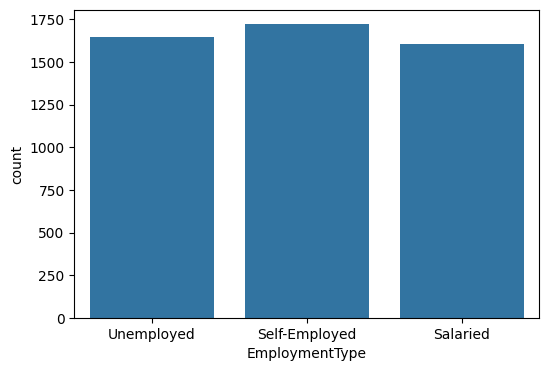

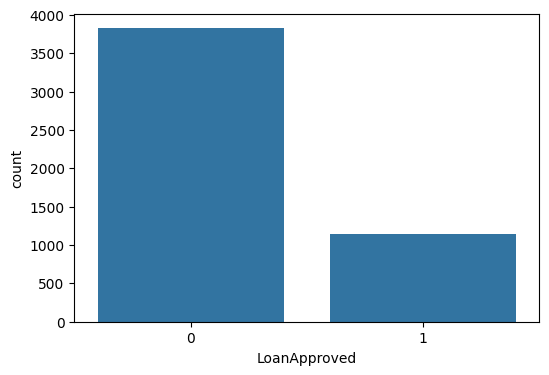

In [ ]:
categorical_cols = ['Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved']
for cols in categorical_cols:
  plt.figure(figsize=(6,4))
  sns.countplot(x = df[cols])

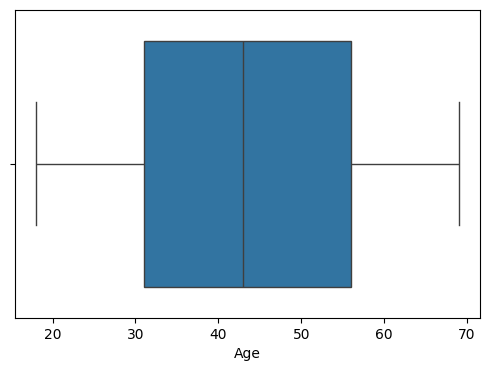

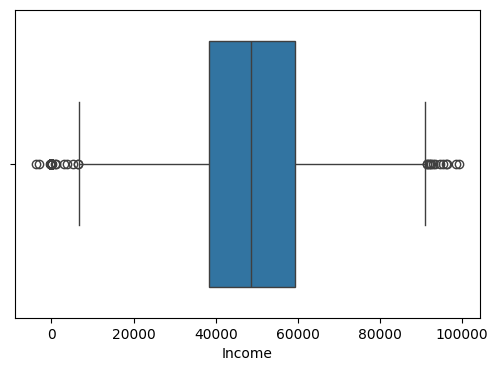

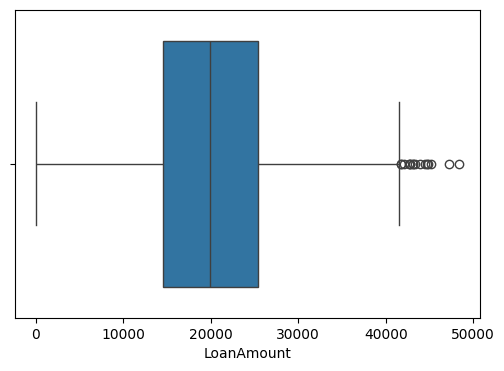

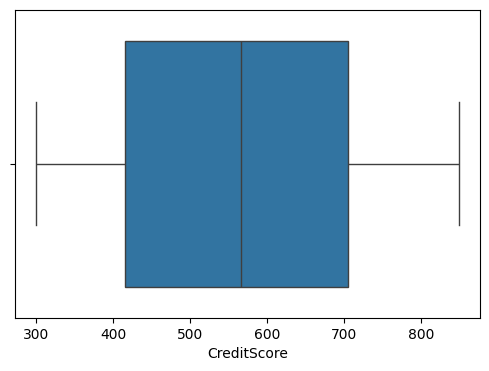

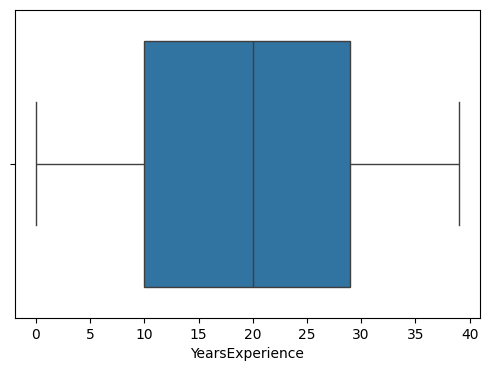

In [ ]:
for cols in numeric_cols:
  plt.figure(figsize=(6,4))
  sns.boxplot(x = df[cols])

<Axes: >

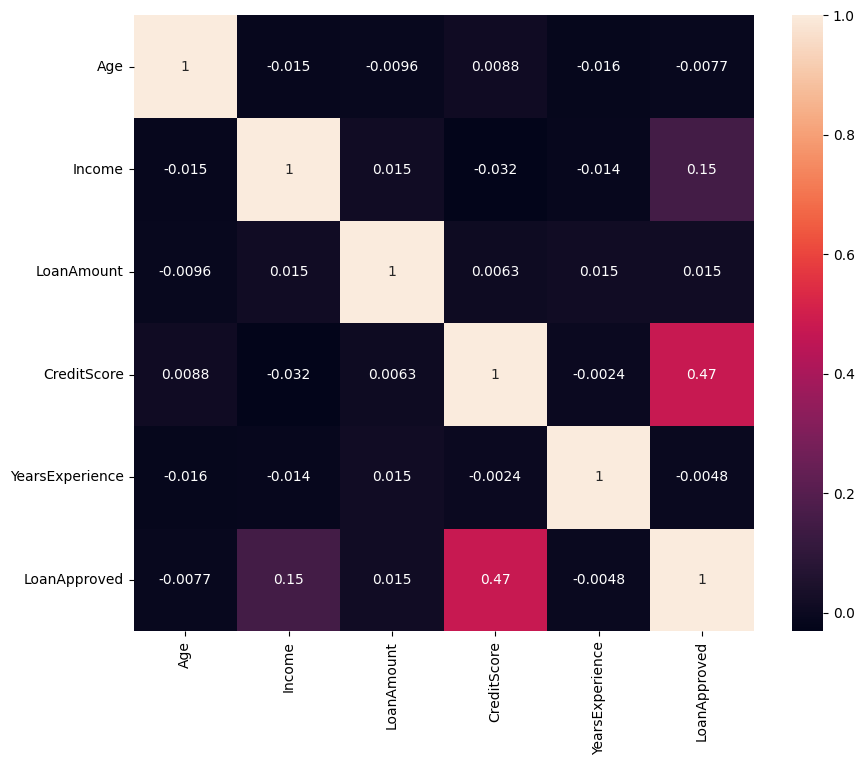

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only = True), annot=True)

In [ ]:
df.shape

(4972, 10)

In [ ]:
df.drop_duplicates(inplace = True)

In [ ]:
df.shape

(4972, 10)

In [ ]:
df.dtypes

,0
Age,int64
Income,float64
LoanAmount,float64
CreditScore,float64
YearsExperience,int64
Gender,object
Education,object
City,object
EmploymentType,object
LoanApproved,int64


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Male,2524
Female,2448


In [ ]:
df['Gender'] = df['Gender'].map({'Male':0, 'Female':1})

In [ ]:
df['Education'].value_counts()

,count
Education,
Bachelors,1210
Masters,1195
PhD,1192
High School,1177
No Education,198


In [ ]:
df['City'].value_counts()

,count
City,
Chicago,1289
San Francisco,1255
Houston,1226
New York,1202


In [ ]:
df['EmploymentType'].value_counts()

,count
EmploymentType,
Self-Employed,1721
Unemployed,1647
Salaried,1604


In [ ]:
df.rename(columns = {'Gender' : 'is_female'}, inplace = True)

In [ ]:
df = pd.get_dummies(df, columns=['Education', 'City', 'EmploymentType'], drop_first=True)

In [ ]:
df = df.astype(int)

In [ ]:
df.head()

,Age,Income,LoanAmount,CreditScore,YearsExperience,is_female,LoanApproved,Education_High School,Education_Masters,Education_No Education,Education_PhD,City_Houston,City_New York,City_San Francisco,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353,31258,675,20,1,0,1,0,0,0,1,0,0,0,1
1,69,57462,23262,586,6,0,0,1,0,0,0,0,0,1,1,0
2,46,44219,26530,781,26,0,1,0,0,0,1,1,0,0,1,0
3,32,56307,11531,549,11,0,0,0,0,1,0,0,1,0,0,1
4,60,37034,27871,500,19,1,0,1,0,0,0,0,0,0,0,1


<Axes: >

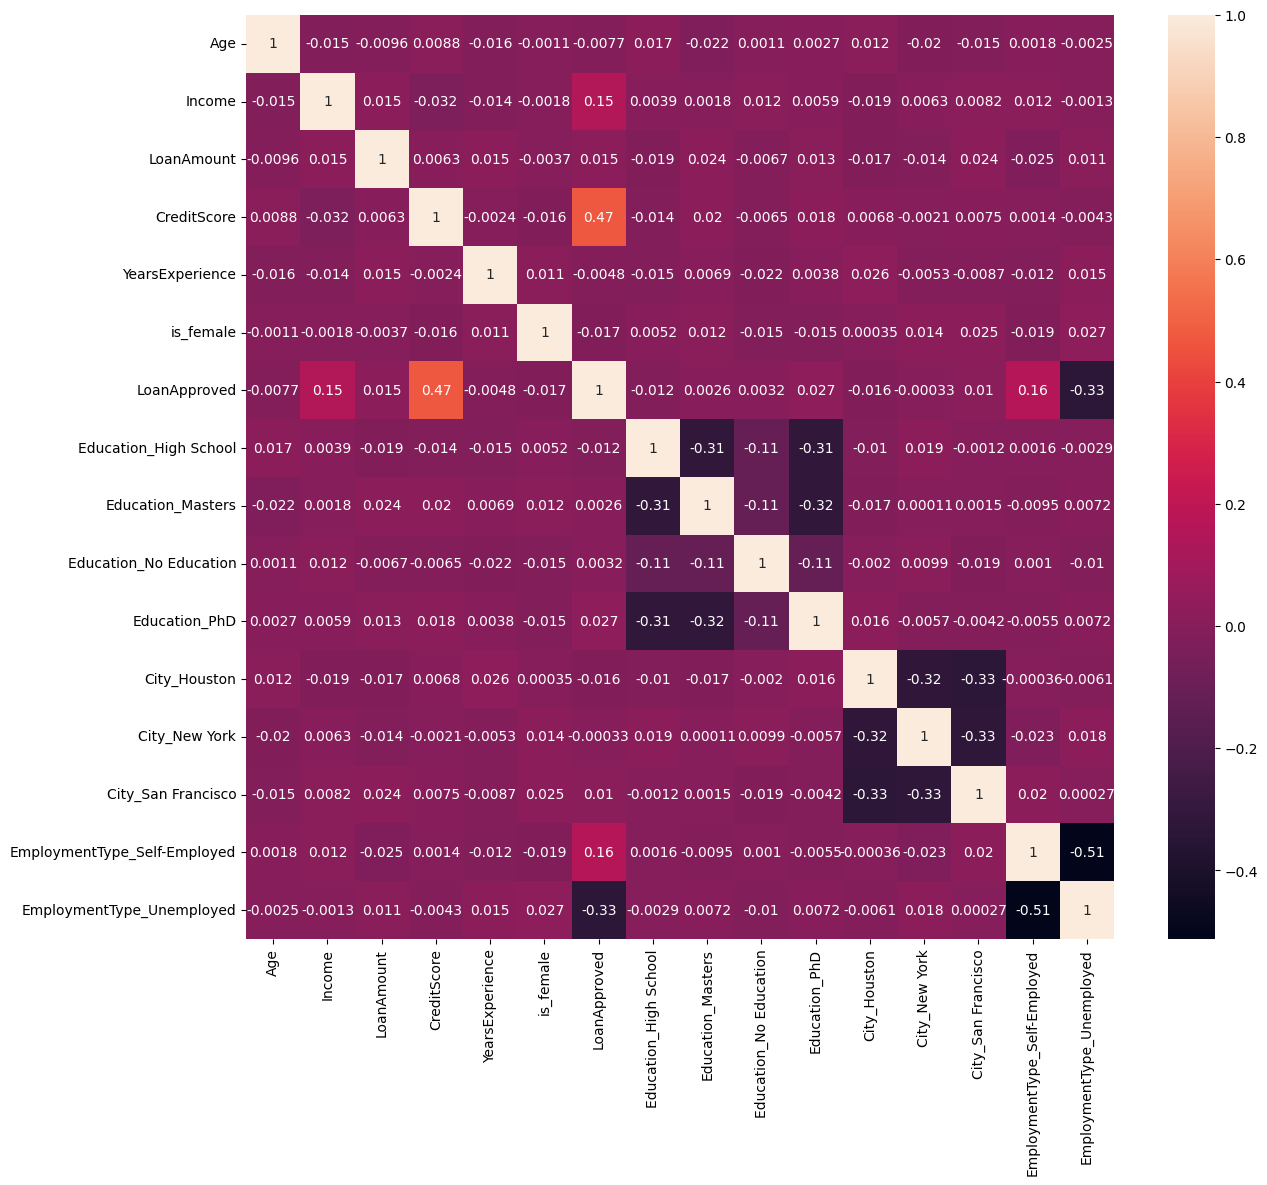

In [ ]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(numeric_only = True), annot=True)

In [ ]:
columns_to_drop = [col for col in df.columns if col not in [
    'CreditScore',
    'Income',
    'EmploymentType_Unemployed',
    'EmploymentType_Self-Employed',
    'LoanApproved'
]]
df_clean = df.drop(columns=columns_to_drop, inplace = True)

In [ ]:
df.head()

,Income,CreditScore,LoanApproved,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,48353,675,0,0,1
1,57462,586,0,1,0
2,44219,781,1,1,0
3,56307,549,0,0,1
4,37034,500,0,0,1


In [ ]:
cols = ['Income', 'CreditScore']
scaler = StandardScaler()
df[cols] = scaler.fit_transform(df[cols])

In [ ]:
df.head()

,Income,CreditScore,LoanApproved,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,0.032959,0.664528,0,0,1
1,0.548724,0.119405,0,1,0
2,-0.201114,1.313776,1,1,0
3,0.483326,-0.107219,0,0,1
4,-0.607939,-0.407343,0,0,1


In [ ]:
from scipy.stats import pearsonr
selected_features = ['Income', 'CreditScore', 'EmploymentType_Self-Employed', 'EmploymentType_Unemployed']
correlation = {
    feature: pearsonr(df[feature], df['LoanApproved'])[0]
    for feature in selected_features
}
correlation_df = pd.DataFrame(list(correlation.items()), columns=['Feature', 'Correlation'])
correlation_df.sort_values(by='Correlation', ascending=False, inplace=True)
correlation_df

,Feature,Correlation
1,CreditScore,0.472672
2,EmploymentType_Self-Employed,0.164560
0,Income,0.153081
3,EmploymentType_Unemployed,-0.332658


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop('LoanApproved', axis = 1)
y = df['LoanApproved']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
r2
n = X_test.shape[0]
p = X_test.shape[1]
adr2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))
adr2

0.3536589178931703